<a href="https://colab.research.google.com/github/ganon-evans-capp/ds-20195-GE-final-project/blob/main/Data_and_the_State_Final_Project_GE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Barcelona Title

Microproject by Ganon Evans for Data and the State, Spring Quarter 2026

Over the last two decades, Barcelona has had waves of antitourist activism protesting increasing costs of living and housing shortages. Using data from the City of Barcelona, AirBnB, and X, this project maps out problem areas and XYZ.

# Background

For the 1992 Olympics, the industrial port city of Barcelona was transformed through urban development into a multicultural city on a scenic Mediterranean beach front [1]. In the decades after, Barcelona became a tourist hotspot. The city estimated that in 2023, it received 26 million tourists compared to its resident population of just 1.5 million people [2]. From 2000 and 2015, the number of cruise passengers stopping in Barcelona quintupled, with 57% of them not even spending the night in the city [1]. Despite the increase in visitors, the residential population near the city center declined by 11% between 2015 and 2019 - that accounts for about 100,000 people [Q].

The proliferation of tourism is not without its critics, who argue that the industry does not create high-paying jobs, inflates local prices, and constrains the housing market. Madrid and Barcelona, Spain's two largest urban centers, have costs of living that are 20% higher than elsewhere in the country; yet, the adjusted purchasing power from higher wages is only 21% higher, meaning that low-income communities with stagnant wages may be forced to move if tourism drives up prices [3]. Barcelona has been identified has one of the top cities in the EU with low housing stock, and between 2013 to 2016, rental income increased by 23% [4].

In 2017, the left-leaning Catalan collective Arran spraypainted tour buses, slashed the tires of rental bicycles, and occupied local beaches with banners reading "For the abolition of holiday rentals."[X]. The same year, Barcelona implemented a moratorium called the Special Tourist Accommodation Plan (PEAUT)   which suspended all new urban planning, licenses, and land management projects related to tourism; the plan was repealed in 2019 after protest by landlords and insufficient economic results [W]. In Summer 2025, water guns became symbols of affordable housing protestors, who targeted hostel residents and their workers [Y]. As of February 2026, Barcelona has a 15 euro nightly tourist task in place, and the parliament of Catalonia has approved a bill that would ban all holiday rentals by 2028 [Z].

THOUGHT PAD:
- Graph comparing cost of living over time to wage growth to tourism growth?
- Comparing 2019 map of tourism allotment to AirBnB sales in 2025


In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [19]:
#quarterly AirBnB data for the last 12 months, recorded December 14th, 2025
airbnb_listings = pd.read_csv("data/listings.csv")
#a nice geojson of Barcelona's neighborhoods, also provided by AirBnB
barcelona_neighborhoods = gpd.read_file("data/neighbourhoods.geojson")

#Barcelona's property transactions data. Not geospatial, so we will have to match it to a the neighborhoods by the neighborhood name.
real_estate_df = pd.read_csv("data/2025_notaris_compravendes_trans_tip_us.csv")

BAR_EPSG = 2062 #Standard for mainland Spain


In [20]:
#Since the real_estate_df is in Catalan, I do some cleaning of the headers
real_estate_df = real_estate_df.rename(columns={"Nom_Barri": "neighbourhood", "Tipologia_Us_Desc": "property_use", "Nombre": "transaction_count"})

Part 1: Property Transactions by Neighbourhood

The transaction data lists how many transactions by property type in each neighborhood. Let's narrow the property transactions to properties labeled as residential units or for tourists. These three categories make up 53% of the rows and are contrasted with things like offices and commercial spaces.

In [21]:
real_estate_df = real_estate_df.loc[real_estate_df["property_use"].isin(["Residencial", "Turístic"])]

real_estate_df["property_use"] = real_estate_df["property_use"].replace({
    "Residencial": "Residential",
    "Turístic": "Tourist"
})

#NA values were listed as "..", so I turned everything into a number and dropped the empty rows
real_estate_df["transaction_count"] = pd.to_numeric(real_estate_df["transaction_count"], errors="coerce")
real_estate_df = real_estate_df.dropna(subset=["transaction_count"])

real_estate_joined_df = barcelona_neighborhoods.merge(real_estate_df, on="neighbourhood", how="right")

neighbourhood_rs_choro = real_estate_joined_df.dissolve(by="neighbourhood", aggfunc={"transaction_count": "sum"}).reset_index()

neighbourhood_rs_choro.to_crs(BAR_EPSG)

,neighbourhood,geometry,transaction_count
0,Can Baró,"POLYGON ((1088586.632 773555.062, 1088586.394 ...",84.0
1,Canyelles,"POLYGON ((1088173.434 776849.453, 1088195.804 ...",40.0
2,Ciutat Meridiana,"POLYGON ((1089479.696 778202.975, 1089472.063 ...",182.0
3,Diagonal Mar i el Front Marítim del Poblenou,"POLYGON ((1093071.675 772903.111, 1093101.691 ...",198.0
4,Horta,"POLYGON ((1087810.531 776787.351, 1087804.686 ...",229.0
...,...,...,...
64,la Vila Olímpica del Poblenou,"POLYGON ((1091974.635 770652.213, 1091975.805 ...",61.0
65,la Vila de Gràcia,"POLYGON ((1088233.725 772181.53, 1088280.47 77...",528.0
66,les Corts,"POLYGON ((1086762.651 770341.627, 1086840.728 ...",368.0
67,les Roquetes,"POLYGON ((1089766.94 777249.743, 1089764.173 7...",236.0


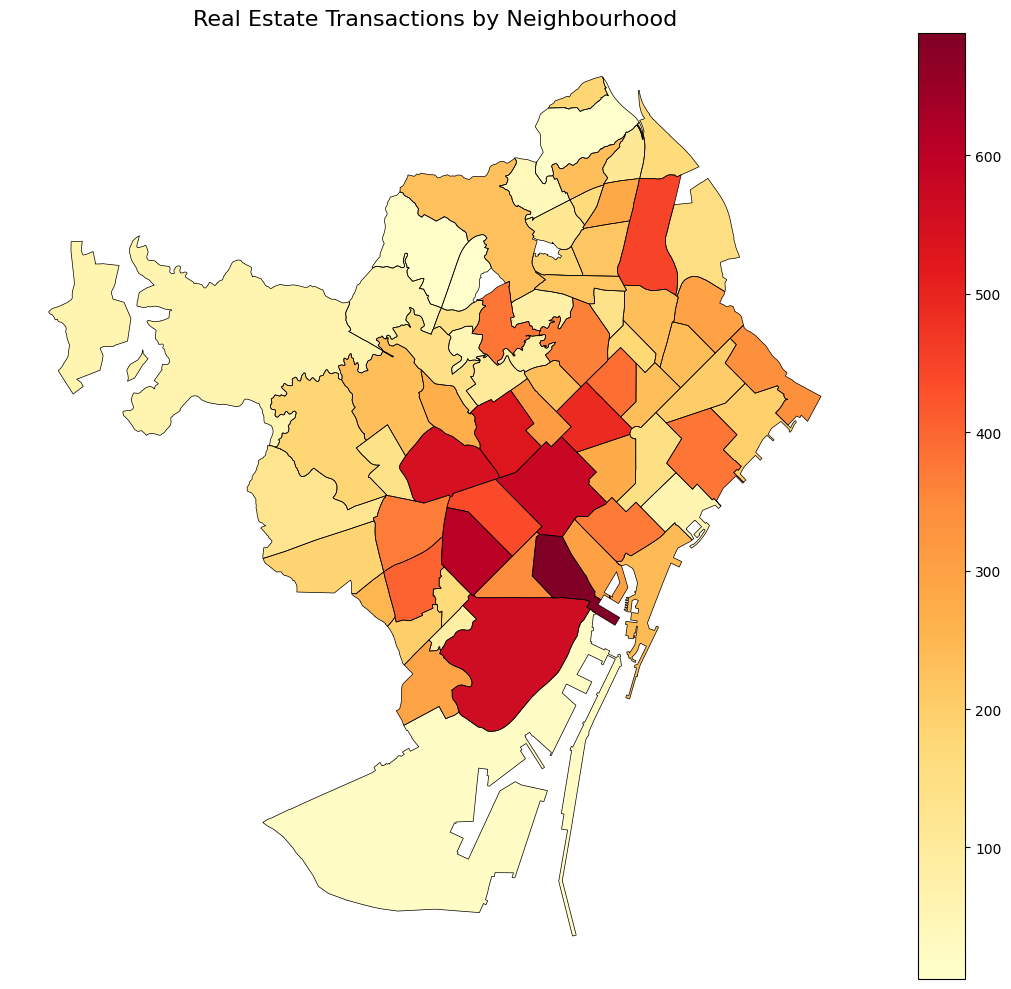

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
ax.set_title("Real Estate Transactions by Neighbourhood", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

I should compare this to maps displaying things like foot traffic, local population, and cost of living.

Part 2: AirBnB Plotting

In [23]:
airbnb_listings

def to_gdf(df):
    geometry = gpd.points_from_xy(df["longitude"], df["latitude"])  # x=lon, y=lat
    return gpd.GeoDataFrame(df, geometry=geometry, crs=4326).to_crs(BAR_EPSG)

airbnb_gdf = to_gdf(airbnb_listings)

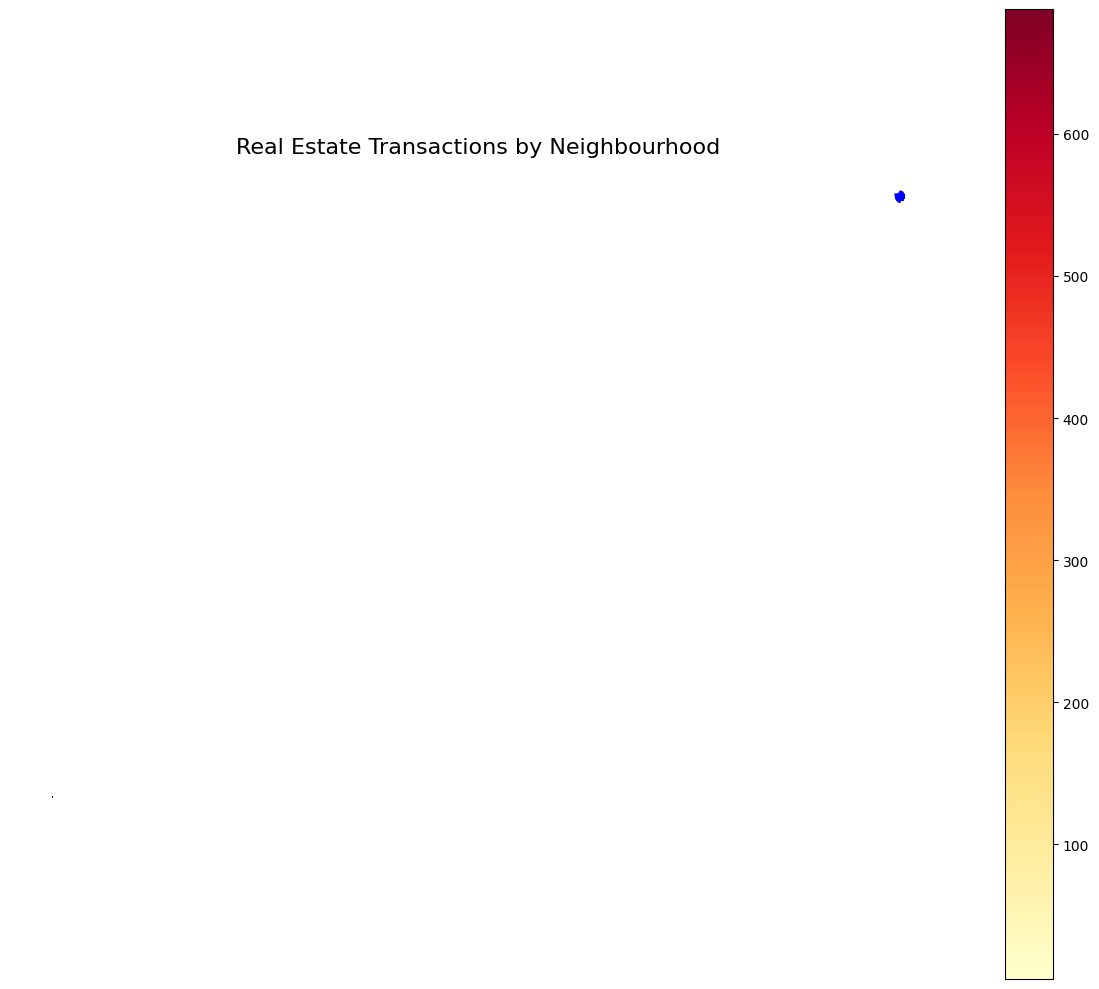

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
airbnb_gdf.plot(
    ax=ax,
    color="blue",
    markersize=1,
    alpha=0.3
)
ax.set_title("Real Estate Transactions by Neighbourhood", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

Citations

[1] https://haroldgoodwin.info/RTPWP/012ManagingTourisminBarcelona.pdf

[2] https://www.greeneuropeanjournal.eu/wp-content/uploads/pdf/overtourism-barcelona-sparks-global-rethinking.pdf

[3] https://www.bde.es/f/webbde/SES/Secciones/Publicaciones/InformesBoletinesRevistas/ArticulosAnaliticos/21/T3/Files/be2103-art29e.pdf

[4] https://www.mdpi.com/2071-1050/10/6/2043

[Q] https://www.euronews.com/2019/07/23/barcelona-s-tourist-headache-as-residential-population-declines-11-since-2015

[W] Special Tourist Accommodation Plan (PEAUT)  https://storymaps.arcgis.com/stories/bda8850641684a40ae4199c449ee5a64

[X] https://pmc.ncbi.nlm.nih.gov/articles/PMC10445860/

[Y] https://www.ap.org/news-highlights/spotlights/2025/how-the-humble-water-gun-became-the-symbol-of-barcelonas-anti-tourism-movement/

[Z]https://www.reuters.com/business/barcelona-doubles-tourism-tax-one-highest-europe-fund-housing-2026-02-25/

https://insideairbnb.com/get-the-data/

https://opendata-ajuntament.barcelona.cat/data/en/dataset/notaris_compravendes_trans_tip_us

https://opendata-ajuntament.barcelona.cat/data/en/dataset/intensitat-activitat-turistica/resource/71499c6a-9947-4e06-88b7-0e26c39d12fe